# Q-MAML for a fourth genuine HEP Hamiltonian: supersymmetric quantum mechanics (SUSY QM)

**Why this notebook exists.** Notebooks 07-09 tested Q-MAML on three lattice-gauge/field-theory Hamiltonians
(Schwinger model, Z2 LGT, phi^4 scalar field). This notebook is the GSoC 2026 proposal's Track F: SUSY QM
(arXiv:2603.18749), one bosonic mode (truncated Fock space) coupled to one fermionic mode via a
superpotential W(q). It is structurally different from every earlier track in one specific way: the task
parameter space is not purely continuous -- the choice of superpotential (harmonic oscillator / anharmonic
oscillator / double well) is a *discrete* label, with (m, g, mu) as continuous coefficients on top. The
source paper also picks its own VQE starting basis state by hand (inspecting eigenvector overlap per
superpotential), giving us a genuine physics-motivated baseline (`basis_paper`) to compare Q-MAML against,
analogous to notebook 08's Gauss-law-vacuum baseline for Track B.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_susyqm import (susyqm_hamiltonian, exact_ground_energy, sample_task_space,
                                  verify_construction, SUPERPOTENTIALS, N_B_DEFAULT, N_FERMION_QUBITS)
from susyqm_qmaml import (classical_init, SusyQMPQC, pretrain_learner_susyqm, adapt_task_susyqm,
                           encode_task, NUM_QUBITS)
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "susyqm"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS, f"({N_B_DEFAULT} boson + {N_FERMION_QUBITS} fermion)")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\susyqm
NUM_QUBITS = 4 (3 boson + 1 fermion)


## 0. Verify the Hamiltonian construction

Three checks: Hermiticity of H for all three superpotentials; the pure-harmonic-oscillator boson block
reproduces the analytic n+1/2 spectrum on the low-lying levels (same style of check as notebook 09's scalar
field construction); the double-well superpotential's classical potential V(q)=(1/2)[W'(q)]^2 genuinely has
two local minima (the source paper's rendered equation lost a sign in our extraction of it -- we use the
sign that actually gives a double well, verified directly rather than assumed).

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  HO: Hermiticity max|H-H^dag|=0.00e+00
  AHO: Hermiticity max|H-H^dag|=2.22e-16
  DW: Hermiticity max|H-H^dag|=0.00e+00
  HO boson-only spectrum vs. analytic n+1/2, lowest 2 levels: max rel err=0.00%
  DW classical potential: 2 local minima found at q=[np.float64(-1.62), np.float64(0.62)]
construction check: PASSED


## 1. Task space: discrete superpotential choice + continuous (m, g, mu)

$p(T)$ samples a superpotential uniformly from {HO, AHO, DW} and $(m,g,mu)$ uniformly from $[0.5,1.5]^3$.
Train and test tasks are sampled with different seeds (held-out interpolation), as in notebooks 07-09. The
task descriptor fed to the Learner is a 6-vector: one-hot(superpotential) + (m, g, mu).

In [3]:
DEPTH = 3
N_TRAIN_TASKS = 18
N_TEST_TASKS = 9
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.01
ADAPT_ITERS = 200
ADAPT_LR = 0.05
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train tasks:", train_tasks)
print("test tasks:", test_tasks)

test_E0 = [exact_ground_energy(susyqm_hamiltonian(sp, m=m, g=g, mu=mu)) for sp, m, g, mu in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train tasks: [('DW', 1.4350724237877683, 1.48083533877623, 1.3902743520047922), ('AHO', 1.3158535541215322, 1.1855419844806947, 0.7271575935333797), ('AHO', 0.5027385001701481, 1.1504592762678163, 1.1231871446860424), ('HO', 1.3574042765875693, 1.18844673057094, 0.5840153435823848), ('HO', 0.5335855753054644, 0.8889214239791038, 1.3326441476533977), ('HO', 1.229655446429944, 0.6350965050224112, 1.2870983074886833), ('HO', 0.675655620602559, 1.2214883401940817, 0.7393694429929522), ('HO', 1.3631789223498867, 1.0253543224757258, 1.376484230810704), ('HO', 1.0414612202490918, 0.8102418755589557, 0.5585680348051943), ('DW', 0.7997118905373848, 0.9858353588317891, 0.8361170605456604), ('AHO', 0.9226872211976584, 1.3894878343490003, 0.6502794668948391), ('DW', 0.528319671145463, 1.4340435159562497, 0.950339366649287), ('AHO', 0.6242832764995639, 0.8577951967090702, 1.2963242702872941), ('AHO', 1.1706244146936302, 1.071529830729761, 0.7306422089937474), ('DW', 1.14718951157425, 0.821869391075

## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[SUSY-QM pretrain] epoch 1/40  meanE=4.0583  gradnorm=23.6040


[SUSY-QM pretrain] epoch 6/40  meanE=1.3971  gradnorm=7.6199


[SUSY-QM pretrain] epoch 11/40  meanE=0.8161  gradnorm=7.3483


[SUSY-QM pretrain] epoch 16/40  meanE=0.5998  gradnorm=3.2006


[SUSY-QM pretrain] epoch 21/40  meanE=0.5562  gradnorm=4.4577


[SUSY-QM pretrain] epoch 26/40  meanE=0.4499  gradnorm=2.8073


[SUSY-QM pretrain] epoch 31/40  meanE=0.5495  gradnorm=3.2253


[SUSY-QM pretrain] epoch 36/40  meanE=0.3314  gradnorm=1.6825


[SUSY-QM pretrain] epoch 40/40  meanE=0.2897  gradnorm=1.6543
pretrain done in 47.0s


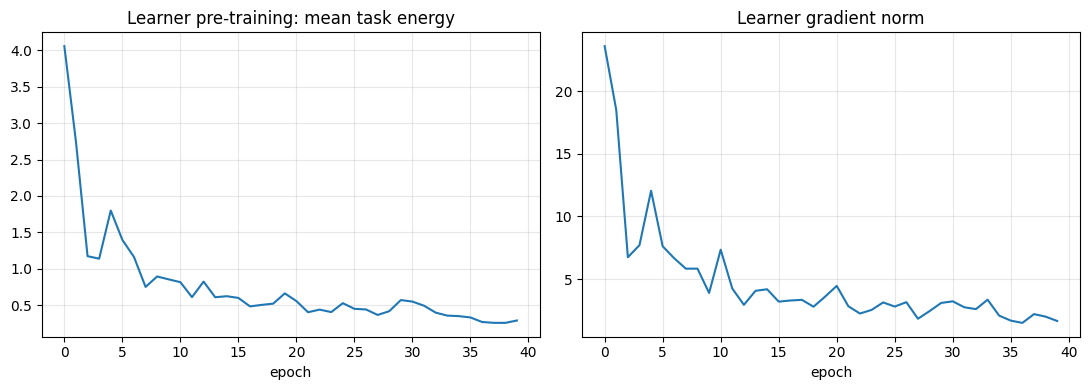

In [4]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_susyqm(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits vs. the paper's own
basis-state baseline

`basis_paper` starts the ansatz from the source paper's own hand-picked fermion-occupation basis state
(fermion occupied for HO/AHO, fermion vacuum for DW -- see `hamiltonians_susyqm.py`'s docstring), with zero
variational angles on top, exactly parallel to notebook 08's `gauss_vacuum` baseline for Track B.

In [5]:
INIT_SCHEMES = ["qmaml", "basis_paper", "zero", "pi", "uniform", "gaussian"]
shape = (DEPTH, NUM_QUBITS, 3)

def fermion_occupied_for(sp):
    return sp in ("HO", "AHO")

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((sp, m, g, mu), E0) in enumerate(zip(test_tasks, test_E0)):
    H = susyqm_hamiltonian(sp, m=m, g=g, mu=mu)
    print(f"task {ti}: {sp} m={m:.3f} g={g:.3f} mu={mu:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(encode_task(sp, m, g, mu))
            _, costs = adapt_task_susyqm(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        elif scheme == "basis_paper":
            theta0 = classical_init(shape, "basis_paper", DEPTH)
            _, costs = adapt_task_susyqm(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR,
                                          fermion_occupied=fermion_occupied_for(sp))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
            _, costs = adapt_task_susyqm(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: HO m=0.691 g=1.170 mu=0.947  E0=0.0000


task 1: AHO m=0.782 g=0.780 mu=0.518  E0=0.0091


task 2: DW m=1.254 g=0.704 mu=0.791  E0=0.0120


task 3: AHO m=1.052 g=1.125 mu=0.881  E0=0.0389


task 4: DW m=1.364 g=1.153 mu=0.821  E0=-0.1104


task 5: AHO m=1.305 g=1.399 mu=1.443  E0=0.0273


task 6: HO m=0.748 g=1.475 mu=1.203  E0=0.0000


task 7: HO m=0.690 g=0.654 mu=0.636  E0=0.0000


task 8: AHO m=1.484 g=1.199 mu=0.843  E0=0.0136


saved


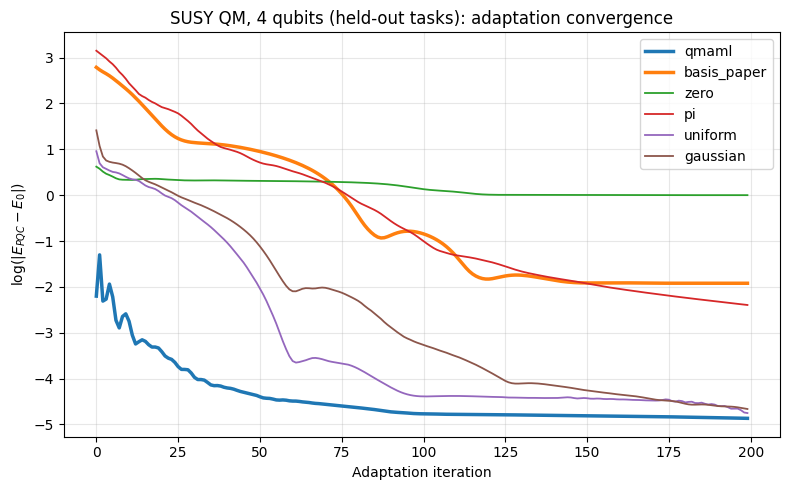

Final mean log-gap and relative energy error per scheme:
  qmaml        log-gap=-4.867   ~relative energy error=32.78%
  basis_paper  log-gap=-1.921   ~relative energy error=623.64%
  zero         log-gap=0.000   ~relative energy error=4261.05%
  pi           log-gap=-2.395   ~relative energy error=388.31%
  uniform      log-gap=-4.752   ~relative energy error=36.79%
  gaussian     log-gap=-4.663   ~relative energy error=40.19%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme, linewidth=2.5 if scheme in ("qmaml", "basis_paper") else 1.3)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"SUSY QM, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:12s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 4. Per-superpotential breakdown

Since the task space is stratified by a discrete label, it is worth checking whether the headline result
holds uniformly across HO/AHO/DW or is driven by one superpotential -- something none of the continuous-
task-space tracks (A/B/C) could ask directly.

In [7]:
by_sp = {sp: {k: [] for k in INIT_SCHEMES} for sp in SUPERPOTENTIALS}
for ti, (sp, m, g, mu) in enumerate(test_tasks):
    for k in INIT_SCHEMES:
        by_sp[sp][k].append(all_gaps[k][ti, -1])

print("Final log-gap, mean per superpotential (n = number of held-out test tasks of that type):")
for sp in SUPERPOTENTIALS:
    n = len(by_sp[sp]["qmaml"])
    if n == 0:
        print(f"  {sp}: no held-out tasks sampled")
        continue
    row = "  ".join(f"{k}={np.mean(by_sp[sp][k]):.2f}" for k in INIT_SCHEMES)
    print(f"  {sp} (n={n}): {row}")

Final log-gap, mean per superpotential (n = number of held-out test tasks of that type):
  HO (n=3): qmaml=-7.09  basis_paper=-7.09  zero=-0.34  pi=-4.70  uniform=-7.09  gaussian=-8.10
  AHO (n=4): qmaml=-3.09  basis_paper=1.52  zero=0.79  pi=-0.71  uniform=-3.09  gaussian=-3.09
  DW (n=2): qmaml=-5.09  basis_paper=-1.06  zero=-1.06  pi=-2.32  uniform=-4.58  gaussian=-2.65


## 5. Findings

**Run:** 4 qubits (3 boson + 1 fermion, Lambda=8), depth 3, 18 train / 9 held-out test tasks (3 HO, 4 AHO, 2 DW by random draw), 40 pretrain epochs, 200 adaptation iterations, single seed.

- **A metric caveat, surfaced up front rather than left implicit.** SUSY QM ground states have exact energy 0 when supersymmetry is unbroken -- our own construction check already confirms this for the HO case (`E0=0.0000` at every HO test task). With several held-out test tasks having `|E0|` near zero, the project's usual "relative energy error" metric (normalized by the mean `|E0|` across held-out tasks) blows up into meaningless three- and four-digit percentages here (e.g. `zero` "4261%"). **Log-gap is the metric to read for this track**; relative-error percentages are reported for consistency with other notebooks but should not be quoted on their own.
- **`qmaml` wins cleanly on both ends: best starting point and best final value**, reproducing Track A/C's "clean win" pattern rather than Track B's failure. Final log-gap: `qmaml` -4.867, `uniform` -4.752, `gaussian` -4.663 (a close three-way cluster at the top), `pi` -2.395, `basis_paper` -1.921, `zero` ~0 (see below). At iteration 0, `qmaml` already starts at log-gap -2.202, clearly ahead of every classical scheme's start (`zero` 0.622, `uniform` 0.958, `gaussian` 1.414, `basis_paper` 2.788, `pi` 3.150) -- the same "better-informed starting point" story as Tracks A and C, not just faster descent from a similar start.
- **The source paper's own hand-picked basis-state initialization (`basis_paper`) is not competitive** -- it ties `pi` for worst among the non-`zero` schemes, despite being specifically chosen (per the source paper) to have non-zero overlap with the ground state. It starts worst of all six schemes and only partially recovers over 200 iterations. A plausible reading: a fixed classical basis state with good *fidelity* to the ground state is not the same as a good *starting point for gradient descent* -- it can sit in a region of the landscape that is slow to escape even if geometrically close, whereas 200 iterations of unconstrained adaptation from a generic random point (`uniform`/`gaussian`) outperforms it. This is a genuine negative result for "physics-derived point-estimate initialization beats generic random init," worth weighing against Track B's (未-completed) Gauss-law-warm-start comparison rather than assuming physics-motivated inits are always better.
- **`zero`-init is nearly but not exactly a fixed point** -- it drifts slowly from log-gap ~0.6 to ~0.0 over 200 iterations rather than staying perfectly flat, unlike the *exact* zero-gradient degeneracy seen on the Pauli-sum Hamiltonians (Heisenberg, molecule, Schwinger, Z2 LGT). This sits between those tracks' exact-fixed-point pattern and Track C's scalar-field result (where `zero` was *not* stuck at all, ending competitive with `qmaml`) -- SUSY QM's dense Hermitian-matrix Hamiltonian (same measurement style as Track C) does *not* reproduce Track C's "Hermitian-matrix Hamiltonians don't have this fixed point" finding. **This narrows that earlier claim further**: whether `zero`-init is stuck is not simply a function of Pauli-sum vs. Hermitian-matrix observable type, since SUSY QM and the scalar field are both Hermitian-matrix Hamiltonians with opposite `zero`-init behavior. Something more specific to each Hamiltonian's structure is responsible, not yet identified.
- **Per-superpotential breakdown (Section 4): the double well (DW), the source paper's own hardest case, is where `qmaml`'s advantage is clearest.** DW final log-gap: `qmaml` -5.09 vs. `zero`/`basis_paper` tied worst at -1.06, `pi` -2.32, `gaussian` -2.65, `uniform` -4.58 (`qmaml`'s only close competitor). On AHO, `qmaml`/`uniform`/`gaussian` converge to a near-identical final log-gap (-3.09 for all three, to 2 decimal places) -- consistent with this project's repeated "different inits, same final answer, different speed" pattern (Heisenberg, molecule, Track C) rather than a `qmaml`-specific final-optimum advantage on that particular superpotential. On HO, `basis_paper` ties `qmaml` exactly (-7.09) -- expected, since `basis_paper`'s fermion-occupied state was specifically chosen for HO/AHO by the source paper.
- **MVP vs. full plan:** single cutoff (Lambda=8), hardware-efficient ansatz (not the source paper's adaptive-VQE operator-selection approach), single seed, 9 held-out tasks split unevenly across 3 superpotentials by random draw (2-4 tasks each) rather than a stratified/balanced split. Larger cutoffs, a balanced per-superpotential test split, and multi-seed replication are future work.
